In [5]:
#create a separate script for bar plots for factor scores (worry, moodiness, and social disinterest) that are colored by domain and subdomain for plotting (keeping separate from other scripts so as to not clutter)
#load necessary packages
import os
import matplotlib.pyplot as plt
from scipy.io import loadmat
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols

#load data - mat file and csv file
os.chdir('/Users/amrithah/Desktop/CalhounLab/Dissertation/Projects/Chapter7_Paper_6_Diss_Clinical_Outcomes/ICA_Results/Depression_ICA_Analyses_Clinical_Outcomes')
data = loadmat('Clinical_Outcomes_Workspace.mat')
os.chdir('/Users/amrithah/Desktop/CalhounLab/Dissertation/Projects/Chapter7_Paper_6_Diss_Clinical_Outcomes/clinical outcomes measures')
df = pd.read_csv("depression_cov_dx_symp_rest_conc_matched_qc_totalbrain(in)_factors.csv")


/opt/anaconda3/lib/python3.13/site-packages/scipy/io/matlab/_mio.py:235: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Considerscipy.io.matlab.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


In [21]:
#rerun regression results here to load variables
# run regressions for depression loading parameters

# --- Load variables ---
depind = data['depind']                    # 2743 x 68
hcind = data['hcind']
age = data['age'].ravel()
Location_ID = data['Location_ID'].ravel()
sex_coded = data['sex_coded'].ravel()
worry_rumination = data['Worry_Rumination'].ravel()
moodiness = data['Moodiness'].ravel()
social_disinterest = data['Social_Disinterest'].ravel()
all_matrices_dep = data['all_matrices_dep']

#modify labels variable as it loads typically with string characters from MATLAB; get rid of this and clean it up with clean_labels

if 'Labels' in data:
    Labels = data['Labels']
    clean_labels = [str(lbl[0]) for lbl in Labels.squeeze()]
else:
    clean_labels = None
    print("⚠️ WARNING: 'Labels' not found in .mat file")

print(clean_labels)

# Add each loading column to df
for i in range(68):
    df[f"loading_{i+1}"] = depind[:, i]

# Storage lists
p_worry = []
T_worry = []
p_mood = []
T_mood = []
p_social = []
T_social = []

for i in range(68):
    loading = f"loading_{i+1}"

    # ANCOVA model including all 3 variables
    formula = (
        f"{loading} ~ age + C(sex_coded) + C(Location_ID) + "
        f"worry_rumination + moodiness + social_disinterest"
    )

    model = ols(formula, data=df).fit()

    # Extract p-values (from ANOVA table)
    anova = sm.stats.anova_lm(model, typ=2)

    p_worry.append(float(anova.loc["worry_rumination", "PR(>F)"]))
    p_mood.append(float(anova.loc["moodiness", "PR(>F)"]))
    p_social.append(float(anova.loc["social_disinterest", "PR(>F)"]))

    # Extract T-statistics (from model coefficients)
    T_worry.append(float(model.tvalues["worry_rumination"]))
    T_mood.append(float(model.tvalues["moodiness"]))
    T_social.append(float(model.tvalues["social_disinterest"]))

# --- FDR correction (Benjamini–Hochberg) ---
q_worry = multipletests(p_worry, method='fdr_bh')[1]
q_mood = multipletests(p_mood, method='fdr_bh')[1]
q_social = multipletests(p_social, method='fdr_bh')[1]

# Build results table
results = pd.DataFrame({
    "Loading": np.arange(1, 69),
    "p_worry": p_worry,
    "q_worry": q_worry,
    "T_worry": T_worry,
    "p_mood": p_mood,
    "q_mood": q_mood,
    "T_mood": T_mood,
    "p_social": p_social,
    "q_social": q_social,
    "T_social": T_social
})

print(results)


['cerebellum', 'cerebellum', 'cerebellum', 'cerebellum', 'cerebellum', 'cerebellum', 'cerebellum', 'cerebellum', 'cerebellum', 'HC-FR', 'HC-FR', 'HC-FR', 'HC-FR', 'HC-FR', 'HC-FR', 'HC-FR', 'HC-FR', 'HC-FR', 'HC-TP', 'HC-TP', 'HC-TP', 'HC-TP', 'HC-TP', 'HC-TP', 'HC-TP', 'HC-TP', 'HC-TP', 'HC-TP', 'HC-IT', 'HC-IT', 'HC-IT', 'SC-BG', 'SC-BG', 'SC-EH', 'SC-EH', 'SC-EH', 'SC-EH', 'SC-ET', 'sensorimotor', 'sensorimotor', 'sensorimotor', 'sensorimotor', 'sensorimotor', 'sensorimotor', 'sensorimotor', 'sensorimotor', 'sensorimotor', 'sensorimotor', 'sensorimotor', 'TN-DM', 'TN-DM', 'TN-DM', 'TN-DM', 'TN-DM', 'TN-DM', 'TN-DM', 'TN-SA', 'TN-SA', 'VI-OC', 'VI-OC', 'VI-OC', 'VI-OC', 'VI-OC', 'VI-OC', 'VI-OC', 'VI-OC', 'VI-OC', 'VI-OC']
    Loading   p_worry   q_worry   T_worry    p_mood    q_mood    T_mood  \
0         1  0.006910  0.041626  2.703499  0.504516  0.897409 -0.667502   
1         2  0.001267  0.023617  3.227137  0.004818  0.109210 -2.821603   
2         3  0.001600  0.023617  3.15960

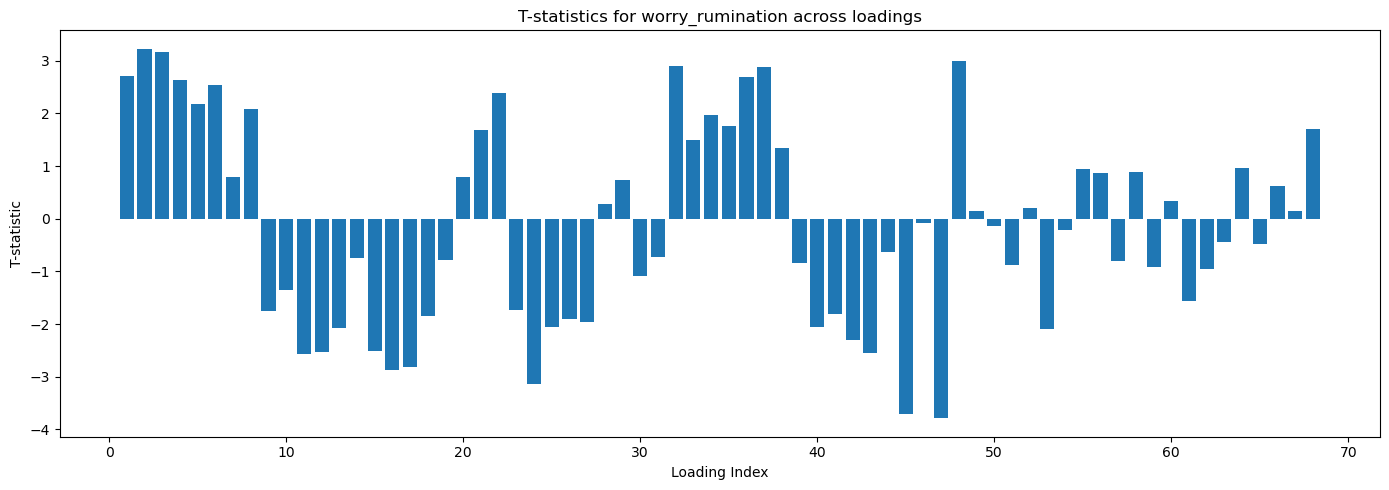

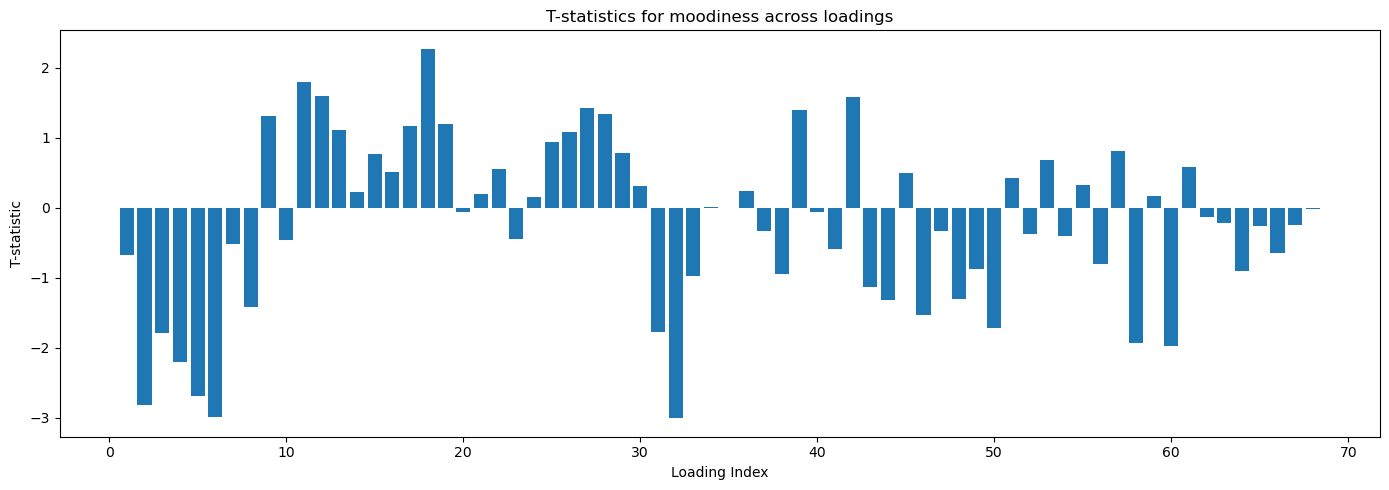

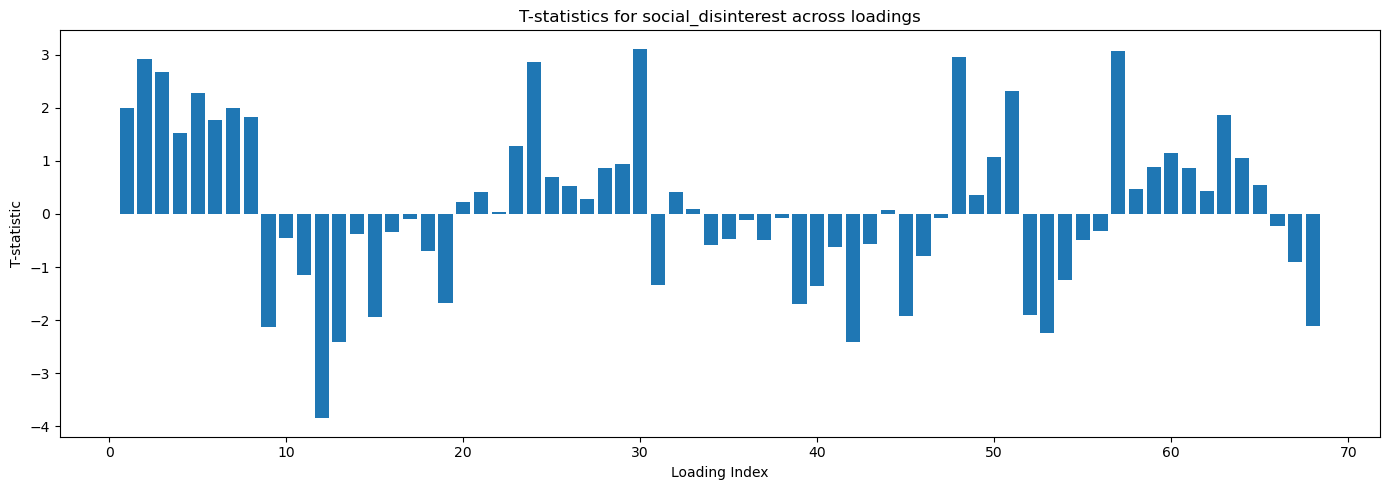

In [16]:
#load original t-stat plots for sanity check for worry, moodiness, and social disinterest

# --- T-STAT PLOT (worry) ---
plt.figure(figsize=(14, 5))
plt.bar(results["Loading"], results["T_worry"])
plt.xlabel("Loading Index")
plt.ylabel("T-statistic")
plt.title("T-statistics for worry_rumination across loadings")
plt.tight_layout()
plt.show()

# --- T-STAT PLOT (moodiness) ---
plt.figure(figsize=(14, 5))
plt.bar(results["Loading"], results["T_mood"])
plt.xlabel("Loading Index")
plt.ylabel("T-statistic")
plt.title("T-statistics for moodiness across loadings")
plt.tight_layout()
plt.show()

# --- T-STAT PLOT (social_disinterest) ---
plt.figure(figsize=(14, 5))
plt.bar(results["Loading"], results["T_social"])
plt.xlabel("Loading Index")
plt.ylabel("T-statistic")
plt.title("T-statistics for social_disinterest across loadings")
plt.tight_layout()
plt.show()

/var/folders/2r/lcd0_jwn383gpby4x6q6v5100000gn/T/ipykernel_39469/2490938128.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(unique_cats))


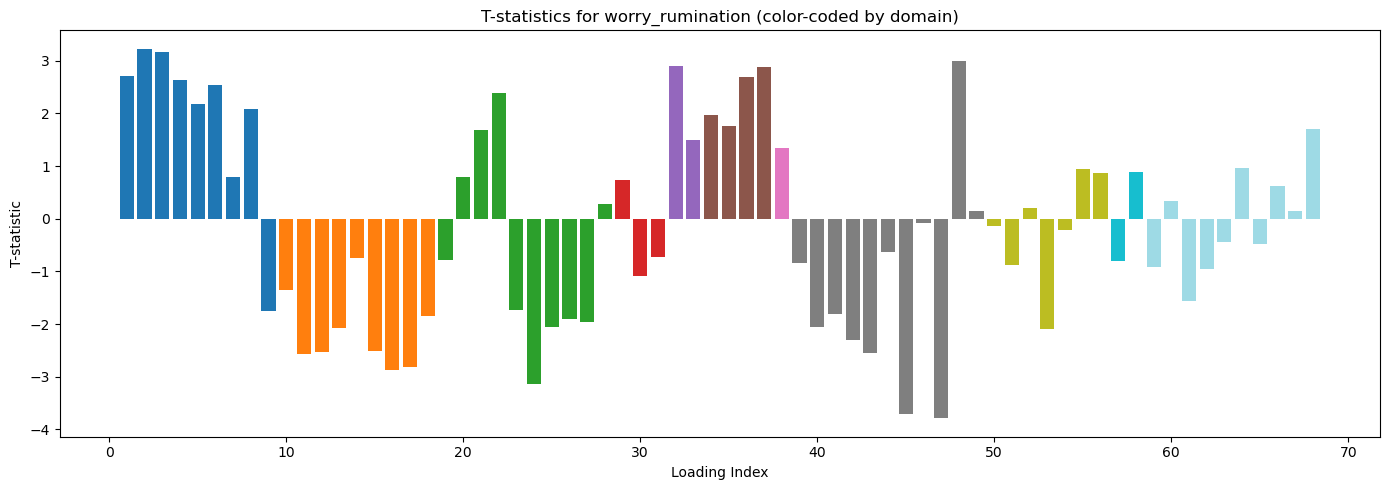

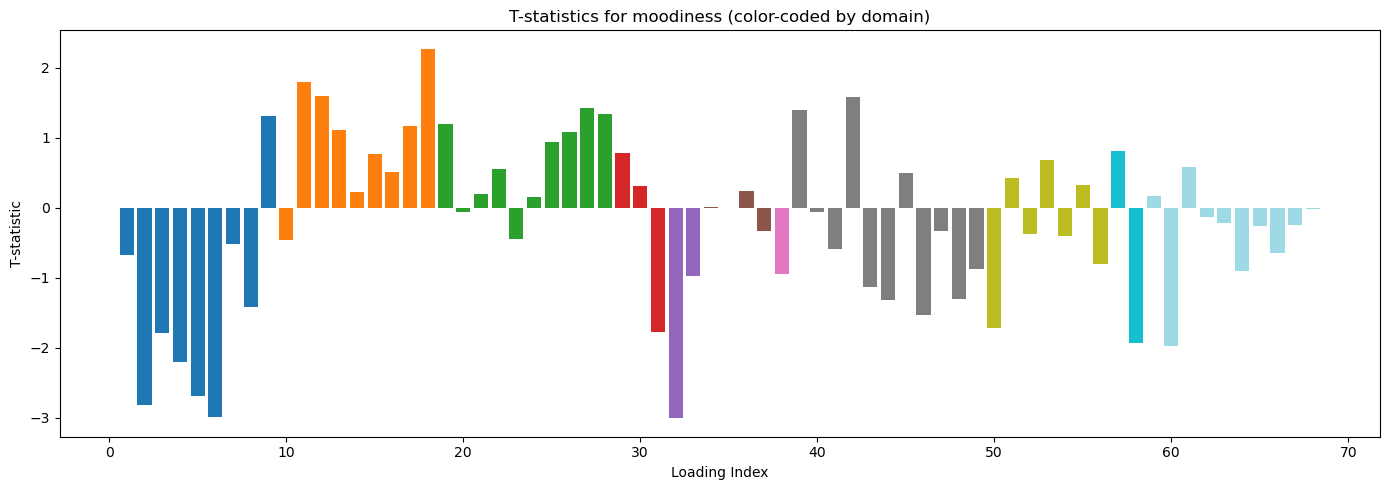

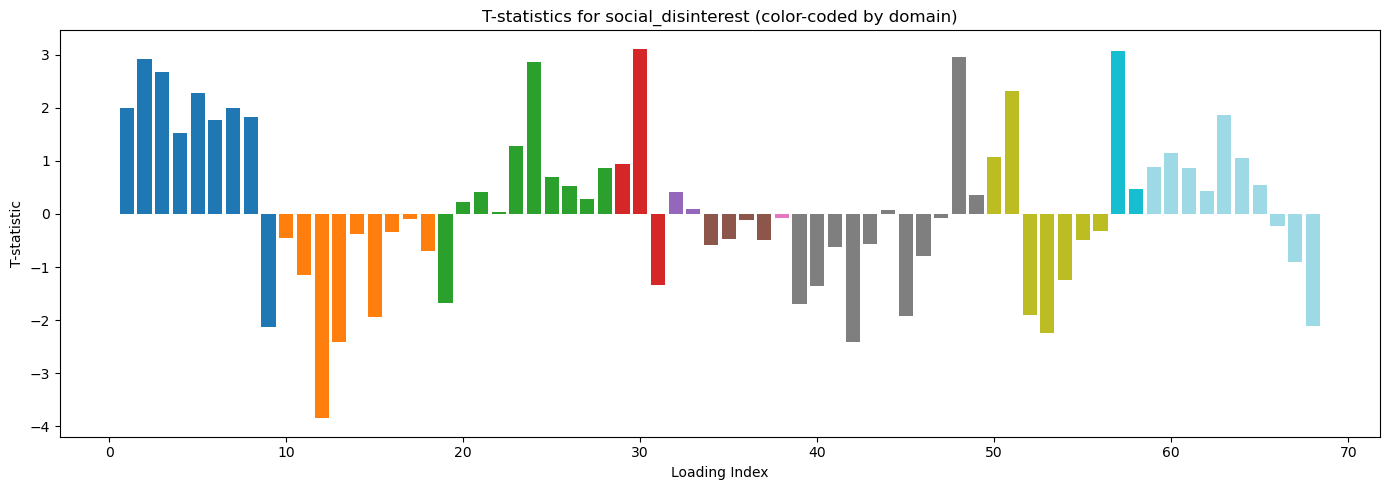

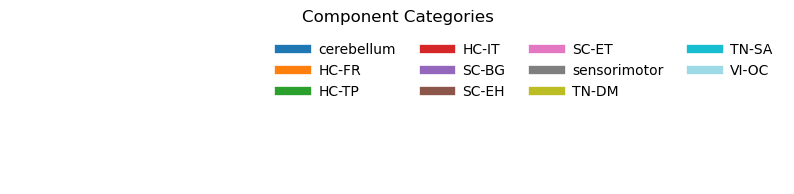

In [ ]:
# now modify these to be colored by domain and subdomain

import matplotlib.cm as cm

# Unique categories from clean_labels (preserves order)
unique_cats = list(dict.fromkeys(clean_labels))

# Assign each category a color
cmap = cm.get_cmap("tab20", len(unique_cats))
category_to_color = {cat: cmap(i) for i, cat in enumerate(unique_cats)}

# Helper: get color for each component number
def get_colors(loadings):
    return [category_to_color[clean_labels[i-1]] for i in loadings]


# --- FIX: use the correct DataFrame which is results ---
df_plot = results

# -------------------------------
# T-STAT PLOT (worry)
# -------------------------------
plt.figure(figsize=(14, 5))
colors = get_colors(df_plot["Loading"].astype(int).tolist())

plt.bar(
    df_plot["Loading"],
    df_plot["T_worry"],
    color=colors
)

plt.xlabel("Loading Index")
plt.ylabel("T-statistic")
plt.title("T-statistics for worry_rumination (color-coded by domain)")
plt.tight_layout()
plt.show()

# -------------------------------
# T-STAT PLOT (moodiness)
# -------------------------------
plt.figure(figsize=(14, 5))
colors = get_colors(df_plot["Loading"].astype(int).tolist())

plt.bar(
    df_plot["Loading"],
    df_plot["T_mood"],
    color=colors
)

plt.xlabel("Loading Index")
plt.ylabel("T-statistic")
plt.title("T-statistics for moodiness (color-coded by domain)")
plt.tight_layout()
plt.show()

# -------------------------------
# T-STAT PLOT (social_disinterest)
# -------------------------------
plt.figure(figsize=(14, 5))
colors = get_colors(df_plot["Loading"].astype(int).tolist())

plt.bar(
    df_plot["Loading"],
    df_plot["T_social"],
    color=colors
)

plt.xlabel("Loading Index")
plt.ylabel("T-statistic")
plt.title("T-statistics for social_disinterest (color-coded by domain)")
plt.tight_layout()
plt.show()

# -------------------------------
# Legend for categories
# -------------------------------
legend_handles = [
    plt.Line2D([0], [0], color=category_to_color[cat], lw=6, label=cat)
    for cat in unique_cats
]

plt.figure(figsize=(10, 2))
plt.legend(handles=legend_handles, ncol=4, frameon=False)
plt.axis("off")
plt.title("Component Categories")
plt.show()


/var/folders/2r/lcd0_jwn383gpby4x6q6v5100000gn/T/ipykernel_39469/1697793331.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(unique_cats))


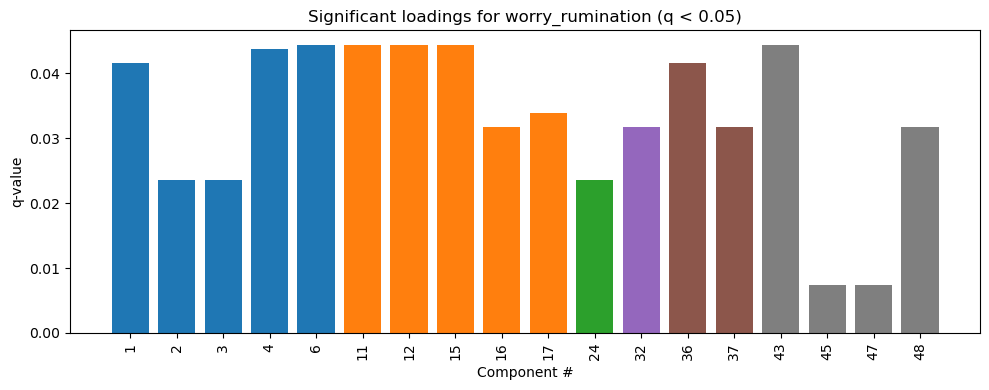

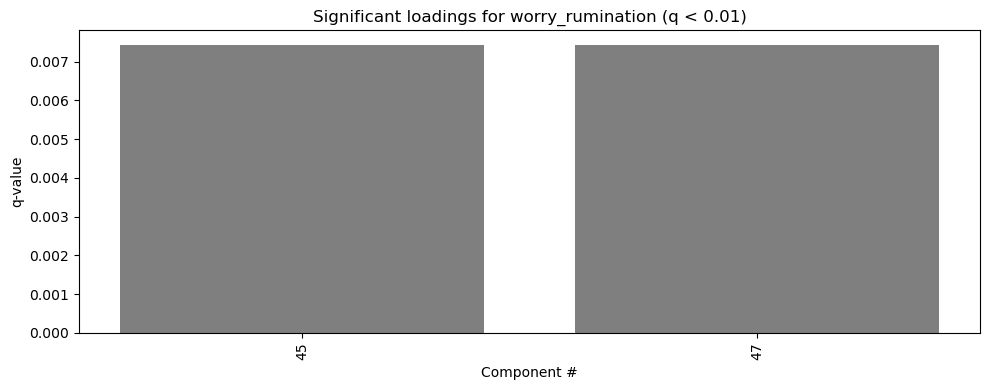

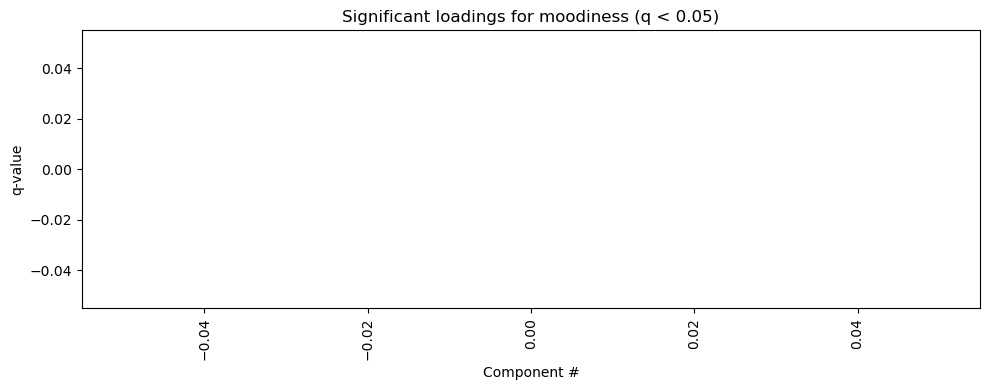

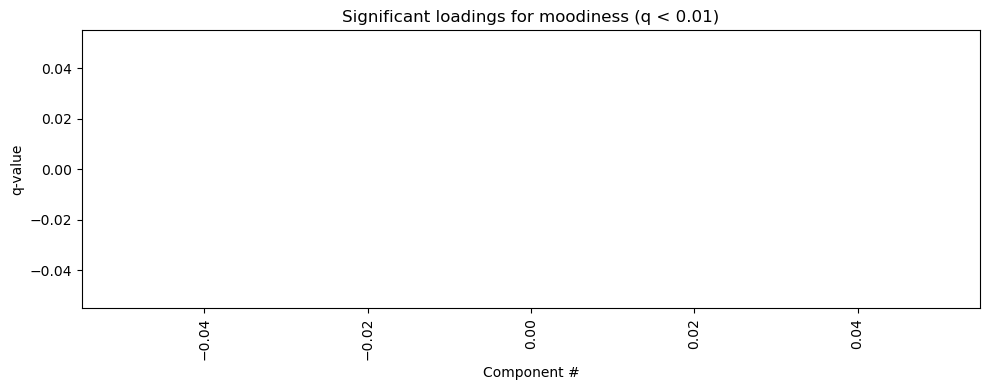

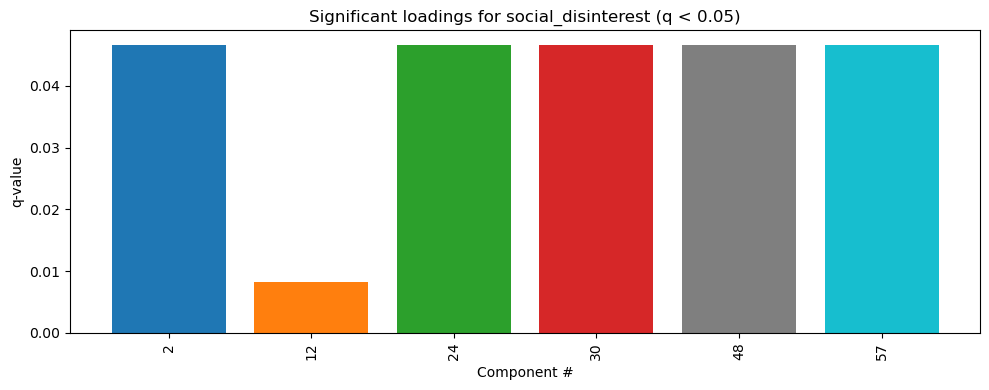

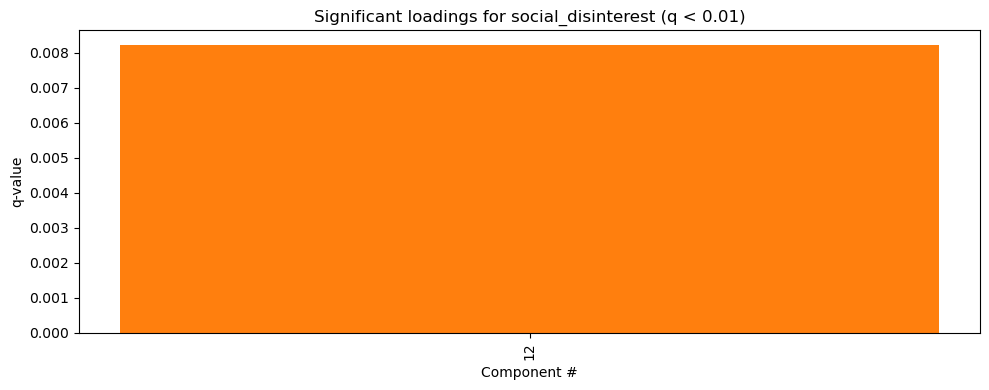

In [23]:
#update color plots for the remaining component bar plots across worry/rumination, moodiness, and social disinterest

import matplotlib.cm as cm

# Unique categories from clean_labels (preserves order)
unique_cats = list(dict.fromkeys(clean_labels))

# Assign each category a color
cmap = cm.get_cmap("tab20", len(unique_cats))
category_to_color = {cat: cmap(i) for i, cat in enumerate(unique_cats)}

# Helper: get color for each component number
def get_colors(loadings):
    return [category_to_color[clean_labels[i-1]] for i in loadings]

df_plot = results 

# for worry, q < 0.05 and q < 0.01

sig = df_plot[df_plot["q_worry"] < 0.05]
sig_loadings = sig["Loading"].astype(int).tolist()
sig_colors = get_colors(sig_loadings)

plt.figure(figsize=(10, 4))
plt.bar([str(i) for i in sig_loadings], sig["q_worry"], color=sig_colors)
plt.xticks(rotation=90)
plt.title("Significant loadings for worry_rumination (q < 0.05)")
plt.xlabel("Component #")
plt.ylabel("q-value")
plt.tight_layout()
plt.show()

sig = df_plot[df_plot["q_worry"] < 0.01]
sig_loadings = sig["Loading"].astype(int).tolist()
sig_colors = get_colors(sig_loadings)

plt.figure(figsize=(10, 4))
plt.bar([str(i) for i in sig_loadings], sig["q_worry"], color=sig_colors)
plt.xticks(rotation=90)
plt.title("Significant loadings for worry_rumination (q < 0.01)")
plt.xlabel("Component #")
plt.ylabel("q-value")
plt.tight_layout()
plt.show()

#for moodiness, q < 0.05 and q < 0.01

sig = df_plot[df_plot["q_mood"] < 0.05]
sig_loadings = sig["Loading"].astype(int).tolist()
sig_colors = get_colors(sig_loadings)

plt.figure(figsize=(10, 4))
plt.bar([str(i) for i in sig_loadings], sig["q_mood"], color=sig_colors)
plt.xticks(rotation=90)
plt.title("Significant loadings for moodiness (q < 0.05)")
plt.xlabel("Component #")
plt.ylabel("q-value")
plt.tight_layout()
plt.show()

sig = df_plot[df_plot["q_mood"] < 0.01]
sig_loadings = sig["Loading"].astype(int).tolist()
sig_colors = get_colors(sig_loadings)

plt.figure(figsize=(10, 4))
plt.bar([str(i) for i in sig_loadings], sig["q_mood"], color=sig_colors)
plt.xticks(rotation=90)
plt.title("Significant loadings for moodiness (q < 0.01)")
plt.xlabel("Component #")
plt.ylabel("q-value")
plt.tight_layout()
plt.show()

#finally, for social disinterest, q < 0.05 and q < 0.01
sig = df_plot[df_plot["q_social"] < 0.05]
sig_loadings = sig["Loading"].astype(int).tolist()
sig_colors = get_colors(sig_loadings)

plt.figure(figsize=(10, 4))
plt.bar([str(i) for i in sig_loadings], sig["q_social"], color=sig_colors)
plt.xticks(rotation=90)
plt.title("Significant loadings for social_disinterest (q < 0.05)")
plt.xlabel("Component #")
plt.ylabel("q-value")
plt.tight_layout()
plt.show()

sig = df_plot[df_plot["q_social"] < 0.01]
sig_loadings = sig["Loading"].astype(int).tolist()
sig_colors = get_colors(sig_loadings)

plt.figure(figsize=(10, 4))
plt.bar([str(i) for i in sig_loadings], sig["q_social"], color=sig_colors)
plt.xticks(rotation=90)
plt.title("Significant loadings for social_disinterest (q < 0.01)")
plt.xlabel("Component #")
plt.ylabel("q-value")
plt.tight_layout()
plt.show()
